#                Similarity Search

## 📘 Project Description

You are given a set of 66 color images stored in the directory image_database, divided into 6 image classes.
Each class contains 11 images.

The objectives of this practical assignment are:

🎯 Objectives

* Compute the similarity between two images.

* Search for the most similar image(s) in the image database using an image provided by the user as a query.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import thisModule as tm
import distances as dist

We have 6 categories.

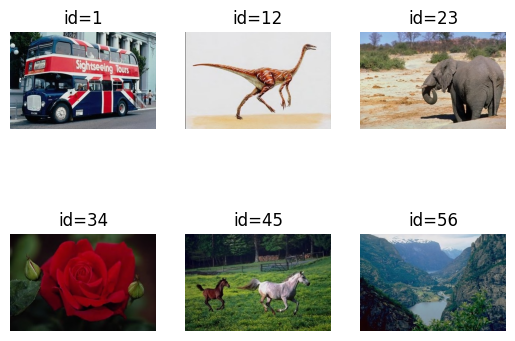

In [2]:
tm.plotFirstFromEachCategory(categoriesCount=6,CategorySize=11,lines=2,columns=3)

We can use eucledian distance to look for similar images to a query image

* first we choose an image

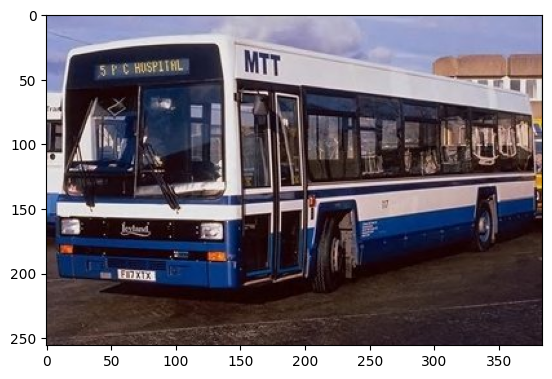

In [3]:
QueryImage=tm.ImageAsArrayNum(7)
plt.imshow(QueryImage)

then we select the 8 nearest images based on euclidian distance between there pixels

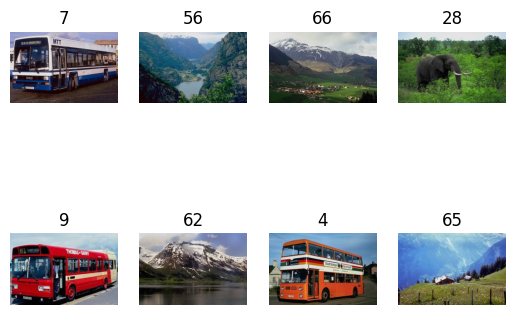

In [4]:
tm.plotResults(dist.distance_pixel(QueryImage))

3/8

In [5]:
AllImages=tm.getImages(nbr_im=66)

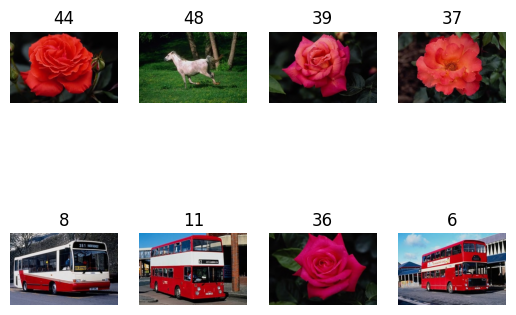

In [4]:
tm.plotResults(dist.distance_histogram(tm.ImageAsArrayNum(44),AllImages))

3/8

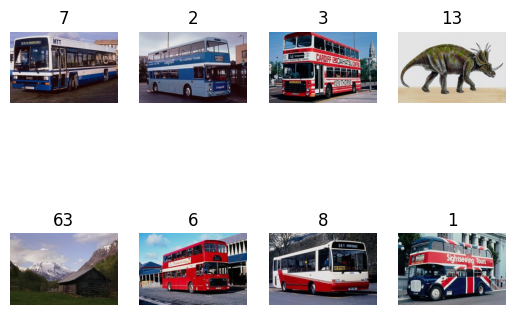

In [7]:
tm.plotResults(dist.disatance_variance(tm.ImageAsArrayNum(7),AllImages))

6/8

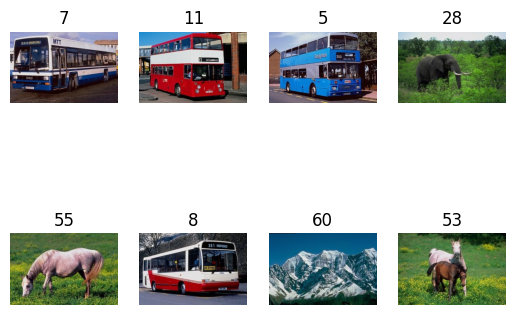

In [8]:
tm.plotResults(dist.disatance_energie(tm.ImageAsArrayNum(7),AllImages))

4/6

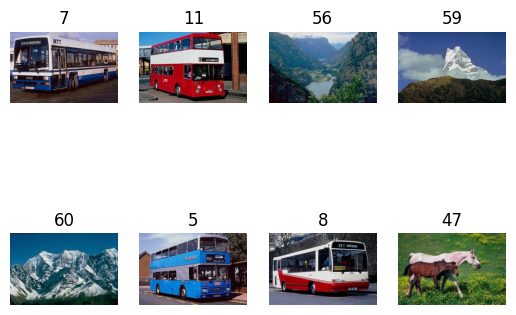

In [9]:
tm.plotResults(dist.disatance_entropie(tm.ImageAsArrayNum(7),AllImages))

4/8

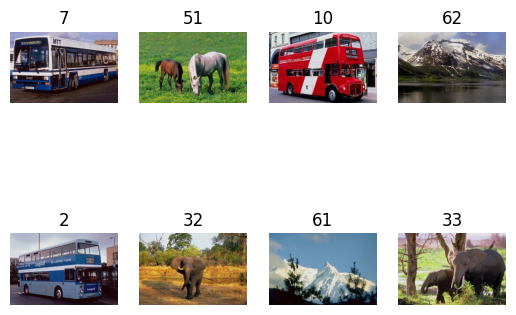

In [10]:
tm.plotResults(dist.disatance_contraste(tm.ImageAsArrayNum(7),AllImages))

3/8

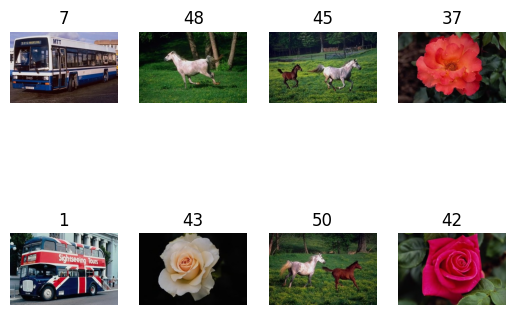

In [12]:
tm.plotResults(dist.disatance_homogenite(tm.ImageAsArrayNum(7),AllImages))

2/8

In [30]:
def disatance_average_colo(query,images,setSize=66,resultNumber=8):
    queryAvgColor=tm.ds.average_color(tm.normalizeImage(tm.rgb2gray(query)))
    D=[]
    for i in range (0,setSize):
        thisAvgColor=tm.ds.average_color(tm.normalizeImage(images[:,:,i]))
        dist=tm.EuclideanDistance(thisAvgColor,queryAvgColor)
        couple=[i+1,dist]
        D.append(couple)
    return sorted(D, key=lambda item: item[1])[:resultNumber]

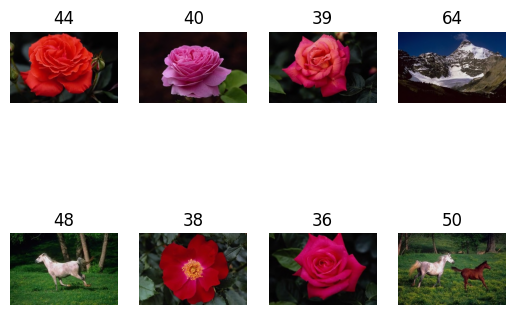

In [32]:
tm.plotResults(disatance_average_colo(tm.ImageAsArrayNum(44),AllImages))

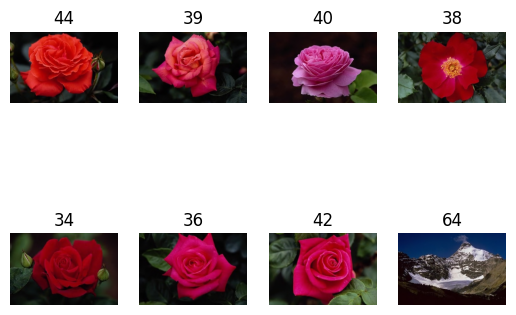

In [33]:
tm.plotResults(dist.disatance_average_color(tm.ImageAsArrayNum(44),AllImages))

4/8

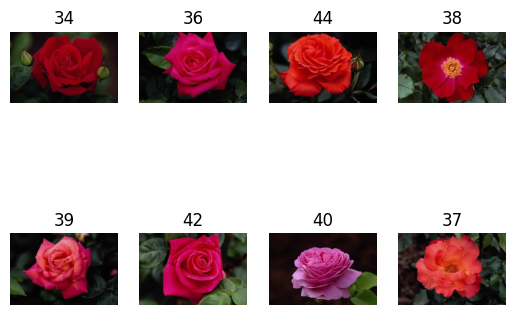

In [29]:
tm.plotResults(dist.disatance_texture(tm.ImageAsArrayNum(7),AllImages))

3/8

In [30]:
def disatance_cooccurence1(query,images,setSize=66,resultNumber=8):
    
    gray=tm.rgb2gray(query).astype(np.uint8)
    print(gray[0,:10])
    queryCooccurence=tm.ds.cooccurence(gray)
    D=[]
    for i in range (0,setSize):
        thisCooccurence=tm.ds.cooccurence(images[:,:,i].astype(np.uint8))
        dist=tm.EuclideanDistance(thisCooccurence.flatten(),queryCooccurence.flatten())
        couple=[i+1,dist]
        D.append(couple)
    return sorted(D, key=lambda item: item[1])[:resultNumber]

[150 146 143 144 147 147 144 140 137 138]


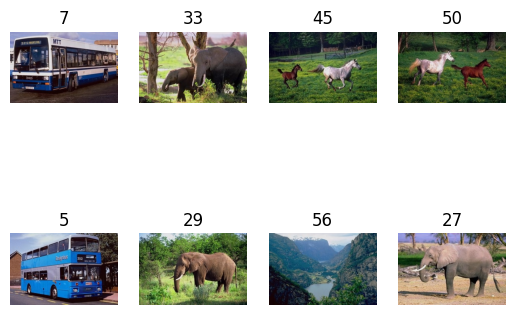

In [31]:
tm.plotResults(disatance_cooccurence1(tm.ImageAsArrayNum(7),AllImages))